# 딥러닝 모델 훈련 노하우 익히기
1. 검증세트 나누고 전처리 과정 배우기
2. 과대적합과 과소적합 알아보기
3. 규제 방법(L1, L2)을 배우고 단일층 신경망에 적용하기
4. 교차 검증을 알아보고 사이킷런으로 수행해보기

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. 검증 데이터 준비하기

### 1. 데이터셋 준비하기

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

### 2-1. 데이터셋을 훈련(train_all), 테스트(test) 데이터셋으로 나누기

In [3]:
cancer = load_breast_cancer()   # 유방암 데이터 불러오기
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y,
                                                            test_size=0.2, random_state=42)

In [4]:
from sklearn.linear_model import SGDClassifier

In [5]:
sgd = SGDClassifier(loss='log_loss', random_state=42) # 로지스틱 손실 함수를 사용하는 모델
sgd.fit(x_train_all, y_train_all)
sgd.score(x_test, y_test)

0.6578947368421053

In [6]:
sgd = SGDClassifier(loss='hinge', random_state=42) # SVM을 사용하는 모델
sgd.fit(x_train_all, y_train_all)
sgd.score(x_test, y_test)

0.9210526315789473

모델의 손실함수를 로지스틱 함수를 쓸 때보다 SVM을 사용할 때 훈련 결과가 더 좋게 나왔다.

- 모델 파라미터 : 가중치 같은 거
- 하이퍼 파라미터 : 여러번 수정하면서 최적의 값을 찾아야 한다.

이처럼 하이퍼 파라미터(사용자가 선택하는 매개변수)를 조정해 모델의 성능을 올리는 작업을 **모델 튜닝**이라고 한다.
그러나 튜닝을 하면 실전에 투입했을 때 성능에 큰 차이가 생길 수 있다. (test 데이터에서 좋은 성능을 내는 것이 목적이어서)

따라서 최대한 test 세트를 사용하지 않고 모델을 튜닝하고자 한다.

### 2-2. 훈련 데이터셋을 훈련(train), 검증(validation) 데이터 세트로 나누기
훈련 세트를 더 나누어서 검증 세트(개발 세트)를 만든다.
훈련:검증:테스트 = 6:2:2

훈련 세트로 훈련하고, 검증 세트로 하이퍼 파라미터 튜닝 후, 테스트 세트로 일반화 성능 추정한다.

In [7]:
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all,
                                                  test_size=0.2, random_state=42)

In [8]:
print(len(x_train), len(x_val))

364 91


In [9]:
sgd = SGDClassifier(loss='log_loss', random_state=42)
sgd.fit(x_train, y_train)
sgd.score(x_val, y_val)

0.6923076923076923

['mean perimeter' 'mean area']


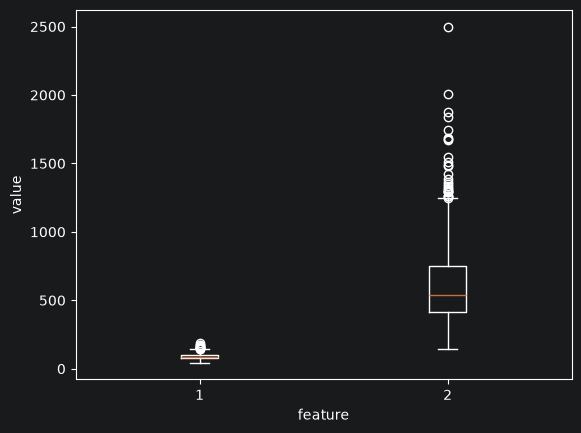

In [10]:
print(cancer.feature_names[[2,3]]) # 2번째, 3번째 특성 확인
plt.boxplot(x_train[:, 2:4])
plt.xlabel('feature')
plt.ylabel('value')
plt.show()

## 데이터 전처리와 특성의 스케일
- 스케일: 특성 값의 범위
위 박스 플롯의 1번 특성과 2번 특성은 스케일이 다르다.

가중치를 업데이트할 때 특성 값(x\[i\])을 곱해서 업데이트하는데 두 값의 범위가 다르면 최적의 가중치를 찾기 어렵다.
- 스케일이 작은 특성은 가중치가 조금씩 업데이트 되고, 스케일이 큰 특성은 가중치가 크게 변한다. -> 좋은 가중치를 찾아가는 속도가 다르다.
- 두 특성이 같은 속도로 좋은 가중치를 찾을 수 있게 스케일을 조정해준다.

### 가중치를 기록하고 학습률을 적용하기
- 학습률(learning rate): 전역 최솟값을 찾을 때, 가중치가 크면 지나칠 수 있기 때문에 학습률을 곱해 가중치를 줄인다.

### 스케일 조정 없이 모델 훈련하기

In [11]:

class SingleLayer1:

    def __init__(self, learning_rate=0.1):  # 학습률 파라미터로 추가
        self.w = None
        self.b = None
        self.losses = []    # 손실값 저장
        self.w_history = [] # 가중치 변화 저장
        self.lr = learning_rate # 학습률

    def forpass(self, x):
        z = np.sum(x*self.w) + self.b
        return z

    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad

    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a

    def score(self, x, y):
        return np.mean(self.predict(x) == y)

    def fit(self, x, y, epochs = 100):
        self.w = np.ones(x.shape[1])
        self.b = 0
        self.w_history.append(self.w.copy())    # 가중치를 기록한다
        np.random.seed(42)  # 무작위로 시드를 지정한다.
        for i in range(epochs):
            loss = 0
            indexes = np.random.permutation(np.arange(len(x)))  # 인덱스를 섞는다
            for i in indexes:
                z = self.forpass(x[i])
                a = self.activation(z)
                err = -(y[i] - a)
                w_grad, b_grad = self.backprop(x[i], err)
                self.w -= w_grad * self.lr  # 학습률을 적용해 업데이트
                self.b -= b_grad * self.lr  # 학습률을 적용해 업데이트

                # 가중치를 기록한다
                self.w_history.append(self.w.copy())
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a)+(1-y[i])*np.log(1-a))

            self.losses.append(loss/len(y))

    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]    # 선형함수 적용
        return np.array(z) > 0



In [12]:
layer1 = SingleLayer1()
layer1.fit(x_train, y_train)
layer1.score(x_val, y_val)

np.float64(0.9120879120879121)

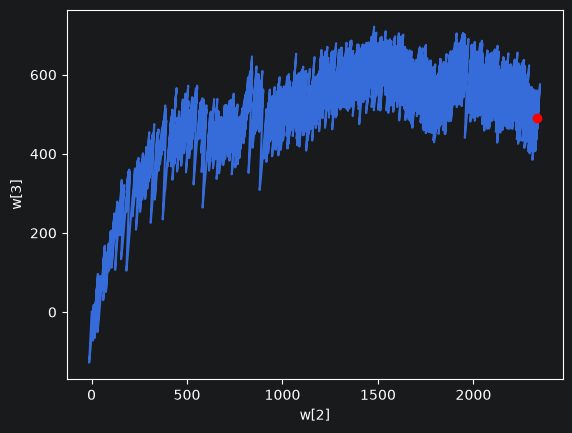

In [13]:
# 변경된 가중치 확인하기
w2 = []
w3 = []

for w in layer1.w_history:
    w2.append(w[2])
    w3.append(w[3])

plt.plot(w2, w3)
plt.plot(w2[-1], w3[-1], 'ro')
plt.xlabel('w[2]')
plt.ylabel('w[3]')
plt.show()

### 가중치를 조정해 모델 훈련하기
#### 표준화(standardzation)
특성 값에서 평균을 빼고 표준편차(s)로 나눈다. -> 평균=0, 분산=1

스케일 조정 방법으로 표준화(standardzation)을 사용한다.

In [14]:
# 1. 넘파이로 표준화 구현하기
train_mean = np.mean(x_train, axis=0)
train_std = np.std(x_train, axis=0)
x_train_scaled = (x_train - train_mean) / train_std

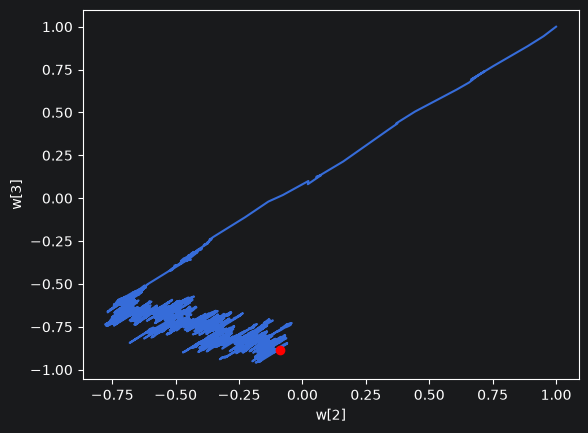

In [15]:
# 2. 모델 훈련하기
layer2 = SingleLayer1()
layer2.fit(x_train_scaled, y_train)

# 결과 시각화
w2 = []
w3 = []
for w in layer2.w_history:
    w2.append(w[2])
    w3.append(w[3])
plt.plot(w2, w3)
plt.plot(w2[-1], w3[-1], 'ro')
plt.xlabel('w[2]')
plt.ylabel('w[3]')
plt.show()

In [16]:
# 3. 모델 성능 평가하기
layer2.score(x_val, y_val)

np.float64(0.37362637362637363)

모델의 성능이 확 떨어져 버렸다. 이유는 검증 데이터셋의 스케일을 조정하지 않았기 때문이다.
모델은 학습 데이터셋과 검증 데이터셋의 스케일이 비슷하다고 가정한다.

In [17]:
# 4. 검증 데이터셋 스케일 조정하기
val_mean = np.mean(x_val, axis=0)
val_std = np.std(x_val, axis=0)
x_val_scaled = (x_val - val_mean) / val_std

In [18]:
# 5. 다시 모델 성능 평가
layer2.score(x_val_scaled, y_val)

np.float64(0.967032967032967)

### 스케일 조정 후 빠지기 쉬운 함정
 - 훈련 데이터셋과 검증 데이터셋이 다른 비율로 스케일 조정되지 않게 주의해야 한다.

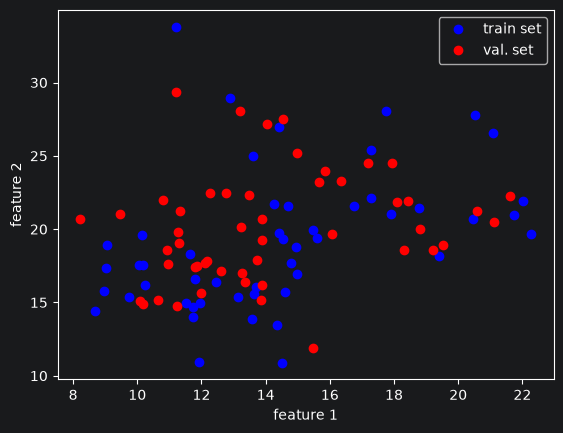

In [19]:
# 1. 원본 훈련 세트와 검증 세트로 산점도 그리기
plt.plot(x_train[:50, 0], x_train[:50, 1], 'bo')
plt.plot(x_val[:50, 0], x_val[:50, 1], 'ro')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend(['train set', 'val. set'])
plt.show()

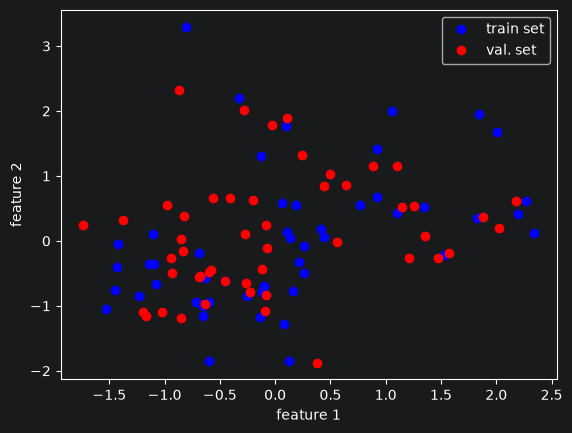

In [20]:
# 2. 전처리한 훈련 세트와 검증 세트로 산점도 그리기
plt.plot(x_train_scaled[:50, 0], x_train_scaled[:50, 1], 'bo')
plt.plot(x_val_scaled[:50, 0], x_val_scaled[:50, 1], 'ro')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend(['train set', 'val. set'])
plt.show()

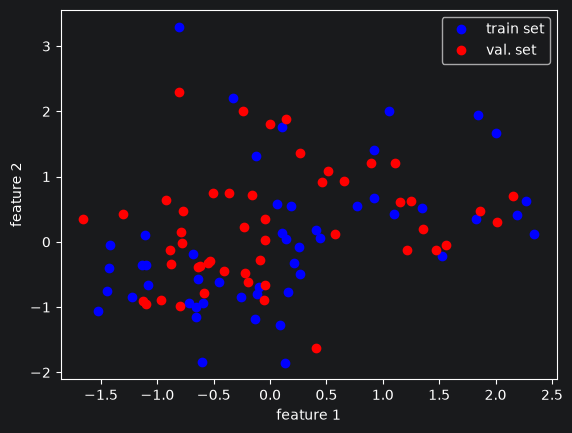

In [21]:
# 3. 올바르게 검증 세트 전처리하기
x_val_scaled = (x_val - train_mean) / train_std

plt.plot(x_train_scaled[:50, 0], x_train_scaled[:50, 1], 'bo')
plt.plot(x_val_scaled[:50, 0], x_val_scaled[:50, 1], 'ro')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend(['train set', 'val. set'])
plt.show()

In [22]:
layer2.score(x_val_scaled, y_val)

np.float64(0.967032967032967)

## 과대적합과 과소적합 알아보기
- 과대적합(over-fitting) : 훈련세트를 과도하게 학습해서 훈련세트에서는 성능이 좋지만 검증세트에서는 성능이 나쁘게 나오는 현상 (분산이 크다)
- 과소적합(under-fitting) : 훈련세트와 검증세트의 정확도 차이가 크지 않지만 전반적인 정확도가 낮은 현상 (편향이 크다)

일반적인 방법
1. 모델을 과대적합 시킴 (뉴런의 개수 or 층의 개수 늘리기)
2. 규제 적용 (가중치 규제, 드롭 아웃, 뉴런 or 층의 개수 줄이기)
3. 적절한 모델 만들기

- 에포크와 손실 함수 / 에포크와 정확도
- 모델 복잡도와 손실 함수 / 모델 복잡도와 정확도


In [23]:
layer4 = SingleLayer1()
layer4.fit(x_train_scaled, y_train, epochs=20)  # 조기 종료(early stopping)
layer4.score(x_val_scaled, y_val)

np.float64(0.989010989010989)

## 규제 방법을 배우고 단일층 신경망에 적용하기

그래프의 기울기가 작을 수록 일반화가 좋다. (기울기 = 가중치)
가중치(기울기)가 너무 작아도 일반화가 너무 잘 되서 과소적합 될 수 있다.
경사하강법 알곡리즘은 손실함수의 값을 낮춰야 하기 때문에 가중치의 값을 높이지 않으려고 애쓰게 된다.

### L1 규제
손실 함수 + L1 노름(norm, 절대값)

**w_grad += alpha * np.sign(w)**

(alpha 파라미터 = 하이퍼 파라미터, sign() = w의 부호만 적용해줌)
- 선형 회귀 + L1 규제 : 라쏘(Lasso)

### L2 규제
손실 함수 + L2 노름의 제곱(유클리드 거리)

**w_grad += alpha * w**
- 선형 회귀 + L2 규제 : 릿지(Ridge)